In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from kneed import KneeLocator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge

In [3]:
data = pd.read_csv('rfm2.csv')
df = pd.DataFrame(data)

data2 = pd.read_csv('instacart.csv')
insta = pd.DataFrame(data2)

In [4]:
insta['order_day'] = pd.to_datetime(insta['order_day'])

insta['order_day'] = (insta['order_day'] - pd.Timestamp("1970-01-01")).dt.days

insta['order_day'] = insta['order_day'].astype(int)

In [5]:
insta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   aisle_id                int64  
 1   product_id              int64  
 2   order_id                int64  
 3   add_to_cart_order       int64  
 4   reordered               int64  
 5   user_id                 int64  
 6   eval_set                object 
 7   order_number            int64  
 8   order_dow               int64  
 9   order_hour_of_day       int64  
 10  days_since_prior_order  float64
 11  product_name            object 
 12  department_id           int64  
 13  aisle                   object 
 14  order_day               int64  
dtypes: float64(1), int64(11), object(3)
memory usage: 3.6+ GB


In [6]:
insta

,aisle_id,product_id,order_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,department_id,aisle,order_day
0,23,12427,2539329,3,0,1,prior,1,2,8,NaN,Original Beef Jerky,19,popcorn jerky,0
1,23,26088,2539329,4,0,1,prior,1,2,8,NaN,Aged White Cheddar Popcorn,19,popcorn jerky,0
2,54,26405,2539329,5,0,1,prior,1,2,8,NaN,XL Pick-A-Size Paper Towel Rolls,17,paper goods,0
3,77,196,2539329,1,0,1,prior,1,2,8,NaN,Soda,7,soft drinks,0
4,91,14084,2539329,2,0,1,prior,1,2,8,NaN,Organic Unsweetened Vanilla Almond Milk,16,soy lactosefree,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32434484,24,24852,2977660,1,1,206209,prior,13,1,12,7.0,Banana,4,fresh fruits,2324
32434485,86,16168,2977660,3,1,206209,prior,13,1,12,7.0,Large Organic Omega3 Brown Eggs,16,eggs,2331
32434486,91,9405,2977660,2,1,206209,prior,13,1,12,7.0,Calcium Enriched 100% Lactose Free Fat Free Milk,16,soy lactosefree,2338
32434487,117,22920,2977660,9,0,206209,prior,13,1,12,7.0,Roasted & Salted Shelled Pistachios,19,nuts seeds dried fruit,2345


In [7]:
data

,user_id,frequency,recency,monetary
0,1,10,30,5.900000
1,2,14,13,13.928571
2,3,12,15,7.333333
3,4,5,0,3.600000
4,5,4,19,9.250000
...,...,...,...,...
206204,206205,3,10,10.666667
206205,206206,67,11,4.253731
206206,206207,16,18,13.937500
206207,206208,49,7,13.816327


In [8]:
features = ['recency', 'frequency', 'monetary']
x = df[features]

In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

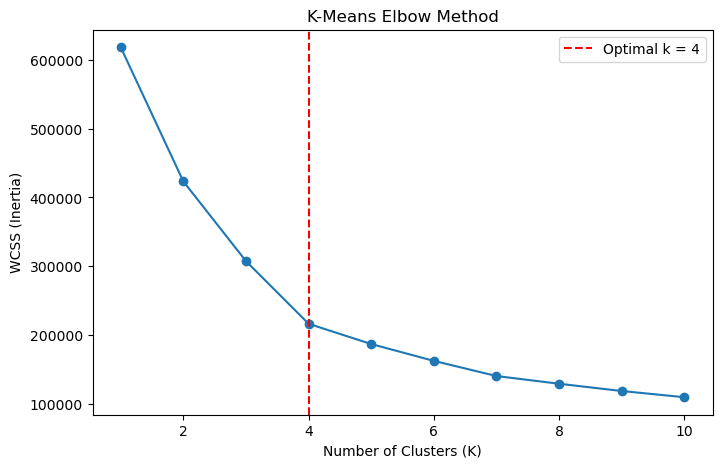

In [10]:
# Apply Elbow method to find the most optimal value of K before initializing clustering
possibleK = list(range(1, 11))
wcss = []

for k in possibleK:
    kmeans = KMeans(n_clusters = k, init = 'k-means++', random_state = 42, n_init = 10)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

kneeLocator = KneeLocator(possibleK, wcss, curve='convex', direction='decreasing')
kValue = kneeLocator.elbow

plt.figure(figsize=(8, 5))
plt.plot(possibleK, wcss, marker='o', linestyle='-')
plt.axvline(x=kValue, color='red', linestyle='--', label=f'Optimal k = {kValue}')
plt.title('K-Means Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.legend()
plt.show()

In [11]:
kmeans = KMeans(n_clusters = kValue, init='k-means++', random_state = 42, n_init = 10)

In [12]:
df['cluster'] = kmeans.fit_predict(x_scaled)

In [13]:
df

,user_id,frequency,recency,monetary,cluster
0,1,10,30,5.900000,2
1,2,14,13,13.928571,0
2,3,12,15,7.333333,1
3,4,5,0,3.600000,1
4,5,4,19,9.250000,2
...,...,...,...,...,...
206204,206205,3,10,10.666667,1
206205,206206,67,11,4.253731,3
206206,206207,16,18,13.937500,0
206207,206208,49,7,13.816327,3


In [14]:
cluster_profiles = df.groupby('cluster').agg({'recency': ['mean', 'median'],'frequency': ['mean', 'median'],'monetary': ['mean', 'median', 'count']}).round(2)

In [15]:
# Four distinct clusters are found. Each with unique behaviors according to the RFM model. 
cluster_profiles

recency        frequency        monetary              
           mean median      mean median     mean median  count
cluster                                                       
0         16.39   15.0     12.03    9.0    19.69  18.40  33593
1          8.32    8.0     12.47   10.0     7.82   7.75  80526
2         27.80   30.0      8.68    6.0     7.75   7.57  70290
3          6.50    6.0     54.88   49.0     9.89   9.36  21800

In [16]:
cluster_labels = {0: 'High Value Customers', 1: 'Frequent Shoppers', 2: 'Inactive Customers',3: 'Loyal Shoppers'}

In [17]:
df['segment'] = df['cluster'].map(cluster_labels)

In [18]:
df

,user_id,frequency,recency,monetary,cluster,segment
0,1,10,30,5.900000,2,Inactive Customers
1,2,14,13,13.928571,0,High Value Customers
2,3,12,15,7.333333,1,Frequent Shoppers
3,4,5,0,3.600000,1,Frequent Shoppers
4,5,4,19,9.250000,2,Inactive Customers
...,...,...,...,...,...,...
206204,206205,3,10,10.666667,1,Frequent Shoppers
206205,206206,67,11,4.253731,3,Loyal Shoppers
206206,206207,16,18,13.937500,0,High Value Customers
206207,206208,49,7,13.816327,3,Loyal Shoppers


In [19]:
print(df['cluster'].value_counts())

cluster
1    80526
2    70290
0    33593
3    21800
Name: count, dtype: int64


In [19]:
# num_orders: How often customers shop
# avg_basket_size: Spend per visit
# avg_days_between_orders: Shopping frequency
# avg_cart_position and num_aisles: How they shop

In [20]:
num_orders = insta.groupby('user_id')['order_id'].nunique().rename('num_orders')

In [21]:
reorder_rate = insta.groupby('user_id')['reordered'].mean().rename('reorder_rate')

In [22]:
avg_basket_size = insta.groupby(['user_id', 'order_id']).size().groupby('user_id').mean().rename('avg_basket_size')

In [23]:
avg_days_between_orders = (insta.groupby('user_id')['days_since_prior_order'].mean().rename('avg_days_between_orders'))

In [24]:
avg_cart_position = (insta.groupby('user_id')['add_to_cart_order'].mean().rename('avg_cart_position'))

In [25]:
num_aisles = (insta.groupby('user_id')['aisle_id'].nunique().rename('num_aisles'))

In [26]:
cust = pd.concat([num_orders,reorder_rate, avg_basket_size, avg_cart_position, avg_days_between_orders, num_aisles], axis=1).reset_index()

cust = cust.merge(df[['user_id', 'cluster']], on = 'user_id', how = 'inner')

In [27]:
cust

,user_id,num_orders,reorder_rate,avg_basket_size,avg_cart_position,avg_days_between_orders,num_aisles,cluster
0,1,10,0.694915,5.900000,3.627119,20.259259,12,2
1,2,14,0.476923,13.928571,8.553846,15.967033,33,0
2,3,12,0.625000,7.333333,4.443182,11.487179,16,1
3,4,5,0.055556,3.600000,2.777778,15.357143,14,1
4,5,4,0.378378,9.250000,5.513514,14.500000,16,2
...,...,...,...,...,...,...,...,...
206204,206205,3,0.250000,10.666667,6.781250,20.666667,17,1
206205,206206,67,0.473684,4.253731,3.835088,4.042705,50,3
206206,206207,16,0.587444,13.937500,8.695067,14.879397,46,0
206207,206208,49,0.707533,13.816327,8.516987,7.442105,63,3


In [28]:
features = ['num_orders', 'avg_basket_size', 'num_aisles', 'avg_cart_position', 'avg_days_between_orders']

target = 'reorder_rate'

In [29]:
rows = []

for cluster_id in sorted(cust['cluster'].dropna().unique()):
    subset = cust[cust['cluster'] == cluster_id].dropna(subset=features + [target]).copy()

    X = subset[features]
    y = subset[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

    rows2 = []
    
    # Bootstrap - Sampling with replacement
    for j in range(1000):
        
        # Randomly choose rows (with replacement) to create for bootstrap dataset
        sample_idx = np.random.choice(len(X_train), size = len(X_train), replace = True)
        
        # Extract location (numeric)
        Xbt = X_train.iloc[sample_idx]
        ybt = y_train.iloc[sample_idx]
        
        # Standardize features
        scaler = StandardScaler()
        Xbt_scaled = scaler.fit_transform(Xbt)
        
        # Ridge model provides better score
        model = Ridge(alpha=1.0)
        model.fit(Xbt_scaled, ybt)
        
        # Append coefficents
        rows2.append(model.coef_)

    #transform into array
    rows2 = np.array(rows2)

    
    coef = rows2.mean(axis = 0)
    std_err = rows2.std(axis = 0, ddof = 1) 
    upper = np.percentile(rows2, 97.5, axis = 0)
    lower = np.percentile(rows2, 2.5, axis = 0)

    for i, feature in enumerate(features):
        rows.append({'cluster': cluster_id, 'feature': feature,'coef': coef[i],'std_err': std_err[i],'lower': lower[i], 'upper': upper[i]})

In [30]:
final = pd.DataFrame(rows).sort_values(by=['cluster', 'coef'], ascending=[True, False])

In [31]:
final

,cluster,feature,coef,std_err,lower,upper
0,0,num_orders,0.170646,0.001016,0.168656,0.172514
1,0,avg_basket_size,0.077659,0.002047,0.073863,0.081772
4,0,avg_days_between_orders,-0.011697,0.000840,-0.013310,-0.010124
3,0,avg_cart_position,-0.049524,0.002122,-0.053726,-0.045492
2,0,num_aisles,-0.054227,0.001267,-0.056790,-0.051721
5,1,num_orders,0.201788,0.000618,0.200632,0.203015
6,1,avg_basket_size,0.130438,0.001456,0.127635,0.133187
9,1,avg_days_between_orders,0.002951,0.000550,0.001854,0.004015
8,1,avg_cart_position,-0.058178,0.001435,-0.061120,-0.055384
7,1,num_aisles,-0.136766,0.000845,-0.138430,-0.135152


In [32]:
final.to_excel("regression2.xlsx", index=False) 
df.to_excel("all_data2.xlsx", index = False)
cust.to_excel("customer_data2.xlsx", index = False)